<a href="https://colab.research.google.com/github/alvarezaguayomiguel1472-commits/Aprendizaje-Automatico/blob/main/U3_S9_Actividad_en_Clases_%C3%81lvarez_Aguayo_Miguel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparativa (Gaussiano, Multinomial)
## Descripción:
- Dataset: spam.csv
- Objetivo: Clasificar correos (spam o ham).

## Autor: Álvarez Aguayo Miguel Alejandro
## Fecha: 21/06/2026

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, classification_report, confusion_matrix

In [85]:
df = pd.read_csv('spam.csv', encoding = 'latin-1')

In [86]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [87]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [88]:
df_nueva_data = df_nueva_data.rename(
    columns = {
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)

In [89]:
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [90]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)

In [92]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

In [93]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)

GaussianNB()

In [94]:
y_pred = gaussian.predict(X_test_vec.toarray())
print(y_pred)

['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [95]:
report = classification_report(y_test, y_pred, target_names=['spam', 'ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



In [96]:
multinomial = MultinomialNB()
multinomial.fit(X_train_vec.toarray(), y_train)

MultinomialNB()

In [97]:
y_pred_multinomial = multinomial.predict(X_test_vec.toarray())
print(y_pred_multinomial)

['ham' 'spam' 'ham' ... 'spam' 'spam' 'ham']


In [98]:
report_multinomial = classification_report(y_test, y_pred_multinomial, target_names=['spam', 'ham'])
print(report_multinomial)

              precision    recall  f1-score   support

        spam       0.99      1.00      0.99      1425
         ham       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672



In [99]:
print("============= Comparación de Clasificadores =============")
print(f"{'Métrica':<15} {'Gaussiano':<15} {'Multinomial':<15}")
print("-" * 55)

#Accuracy
accuracy_gaussiano = accuracy_score(y_test, y_pred)
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
print(f"{'Accuracy':<15} {accuracy_gaussiano:<15.4f} {accuracy_multinomial:<15.4f}")

# Precision
precision_gaussiano = precision_score(y_test, y_pred, pos_label='spam')
precision_multinomial = precision_score(y_test, y_pred_multinomial, pos_label='spam')
print(f"{'Precision':<15} {precision_gaussiano:<15.4f} {precision_multinomial:<15.4f}")

#F1
f1_gaussiano = f1_score(y_test, y_pred, pos_label = 'spam')
f1_multinomial = f1_score(y_test, y_pred_multinomial, pos_label = 'spam')
print(f"{'F1':<15} {f1_gaussiano:<15.4f} {f1_multinomial:<15.4f}")

#Recall

recall_gaussiano = recall_score(y_test, y_pred, pos_label = 'spam')
recall_multinomial = recall_score(y_test, y_pred_multinomial, pos_label = 'spam')
print(f"{'Recall':<15} {recall_gaussiano:<15.4f} {recall_multinomial:<15.4f}")



============= Comparación de Clasificadores =============
Métrica         Gaussiano       Multinomial    
-------------------------------------------------------
Accuracy        0.9061          0.9856         
Precision       0.6257          0.9705         
F1              0.7405          0.9504         
Recall          0.9069          0.9312         


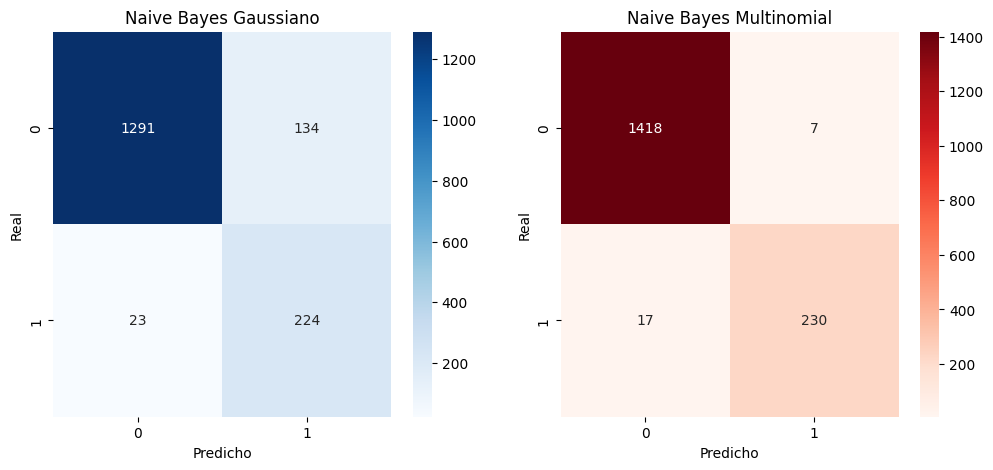

In [100]:
# Graficos de Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

matriz_confusion_gaussiano = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz_confusion_gaussiano, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Naive Bayes Gaussiano')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

matriz_confusion_multinomial = confusion_matrix(y_test, y_pred_multinomial)
sns.heatmap(matriz_confusion_multinomial, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('Naive Bayes Multinomial')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.show()

Comparando ambos modelos, hay una diferencia muy significativa entre ellos, siendo muy superior el modelo Multinomial con un mejor rendimiento y mejores resultados en la evaluacion de métricas.